# **Dealing with Overfitting**
1) Batch Normalization
2) L2 Regularization
3) Drop out

# **Without Batch Normalization**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


<Sequential name=sequential_3, built=True>
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8735 - loss: 0.4403 - val_accuracy: 0.9590 - val_loss: 0.1327
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9683 - loss: 0.1036 - val_accuracy: 0.9693 - val_loss: 0.0996
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9783 - loss: 0.0699 - val_accuracy: 0.9775 - val_loss: 0.0791
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9835 - loss: 0.0535 - val_accuracy: 0.9750 - val_loss: 0.0808
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9870 - loss: 0.0409 - val_accuracy: 0.9729 - val_loss: 0.0901
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9889 - loss: 0.0327 - val_accuracy: 0.9771 - val_loss: 0.0900
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0251 - val_accuracy: 0.9782 - val_loss: 0.0832
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3m

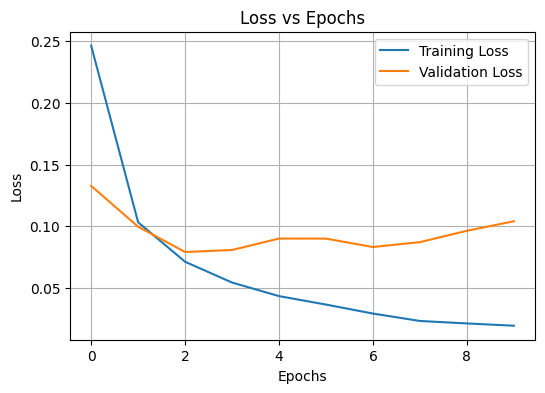

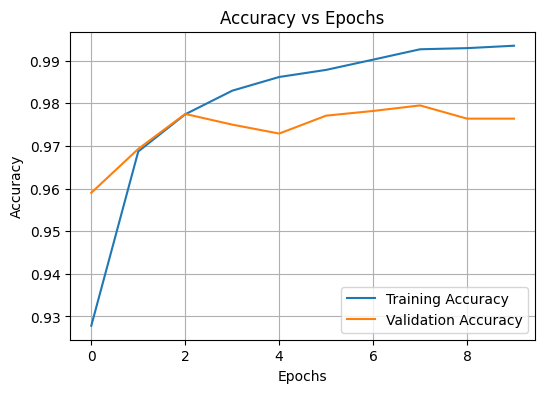

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.datasets import mnist

(X_train , y_train) , (X_test , y_test) = mnist.load_data()
X_train=X_train/255.0
X_test=X_test/255.0

# print(X_train)
# print(X_test)

model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')

])
print(model)

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model_fit=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))
# print(model_fit["history"].history)

plt.figure(figsize=(6,4))
plt.plot(model_fit.history['loss'], label='Training Loss')
plt.plot(model_fit.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model_fit.history['accuracy'], label='Training Accuracy')
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()





# **With Batch Normalization**

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8802 - loss: 0.4034 - val_accuracy: 0.9606 - val_loss: 0.1270
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9622 - loss: 0.1220 - val_accuracy: 0.9592 - val_loss: 0.1344
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9717 - loss: 0.0929 - val_accuracy: 0.9741 - val_loss: 0.0824
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9767 - loss: 0.0747 - val_accuracy: 0.9754 - val_loss: 0.0806
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9796 - loss: 0.0643 - val_accuracy: 0.9786 - val_loss: 0.0724
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9825 - loss: 0.0561 - val_accuracy: 0.9761 - val_loss: 0.0821
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9835 - loss: 0.0506 - val_accuracy: 0.9775 - val_loss: 0.0808
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9849 - loss: 0.0454 - 

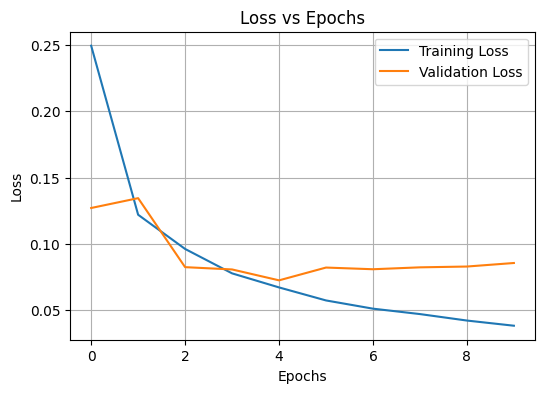

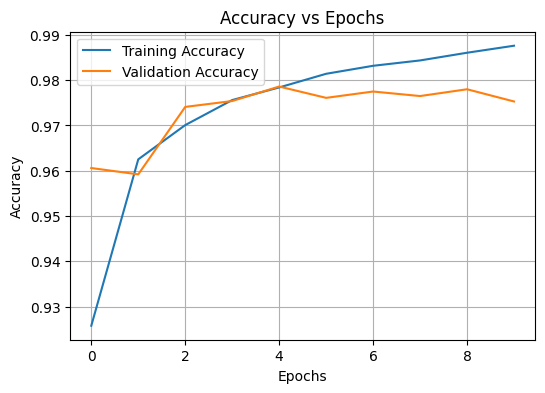

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.datasets import mnist

(X_train , y_train) , (X_test , y_test) = mnist.load_data()
X_train=X_train/255.0
X_test=X_test/255.0

X_train=X_train.reshape(-1,28*28)
X_test=X_test.reshape(-1,28*28)

# print(X_train)
# print(X_test)

model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,)))
model.add(BatchNormalization())
model.add(Dense(64,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(10,activation='softmax'))

# print(model)

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model_fit=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))
# print(model_fit["history"].history)

plt.figure(figsize=(6,4))
plt.plot(model_fit.history['loss'], label='Training Loss')
plt.plot(model_fit.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model_fit.history['accuracy'], label='Training Accuracy')
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()


# **L2 Normalization**

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8542 - loss: 1.2922 - val_accuracy: 0.9162 - val_loss: 0.5352
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9211 - loss: 0.5167 - val_accuracy: 0.9249 - val_loss: 0.4636
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9339 - loss: 0.4478 - val_accuracy: 0.9443 - val_loss: 0.3965
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9398 - loss: 0.4045 - val_accuracy: 0.9408 - val_loss: 0.3828
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9441 - loss: 0.3753 - val_accuracy: 0.9514 - val_loss: 0.3402
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9479 - loss: 0.3514 - val_accuracy: 0.9526 - val_loss: 0.3223
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9496 - loss: 0.3358 - val_accuracy: 0.9473 - val_loss: 0.3294
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9493 - loss: 0.3283 - 

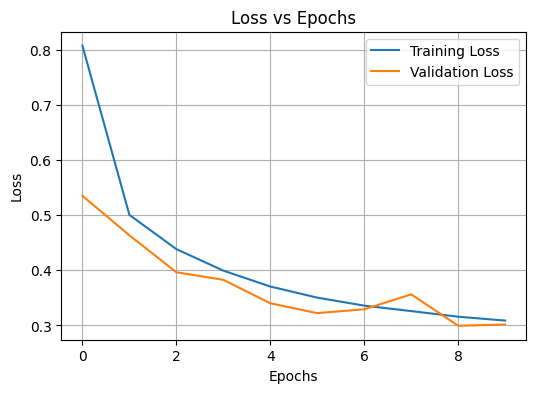

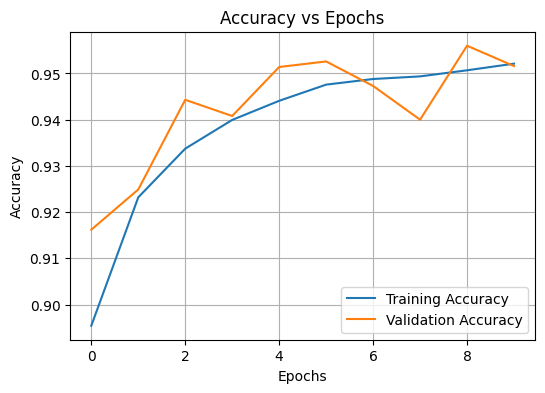

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.datasets import mnist
from tensorflow.keras.regularizers import L2

(X_train , y_train) , (X_test , y_test) = mnist.load_data()
X_train=X_train/255.0
X_test=X_test/255.0

X_train=X_train.reshape(-1,28*28)
X_test=X_test.reshape(-1,28*28)

# print(X_train)
# print(X_test)

model=Sequential()
model.add(Dense(128,activation='relu',input_shape=(784,),kernel_regularizer=L2(0.01)))
# model.add(BatchNormalization())
model.add(Dense(64,activation='relu',kernel_regularizer=L2(0.01)))
# model.add(BatchNormalization())
model.add(Dense(10,activation='softmax'))

# print(model)

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model_fit=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))
# print(model_fit["history"].history)

plt.figure(figsize=(6,4))
plt.plot(model_fit.history['loss'], label='Training Loss')
plt.plot(model_fit.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(model_fit.history['accuracy'], label='Training Accuracy')
plt.plot(model_fit.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()


# **Dropout**

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7926 - loss: 0.6556 - val_accuracy: 0.9548 - val_loss: 0.1493
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9399 - loss: 0.2059 - val_accuracy: 0.9657 - val_loss: 0.1143
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9541 - loss: 0.1537 - val_accuracy: 0.9722 - val_loss: 0.0933
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9595 - loss: 0.1378 - val_accuracy: 0.9740 - val_loss: 0.0888
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9635 - loss: 0.1228 - val_accuracy: 0.9730 - val_loss: 0.0904
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9670 - loss: 0.1100 - val_accuracy: 0.9767 - val_loss: 0.0821
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9691 - loss: 0.1014 - val_accuracy: 0.9775 - val_loss: 0.0794
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9710 - loss: 0.0939 - 

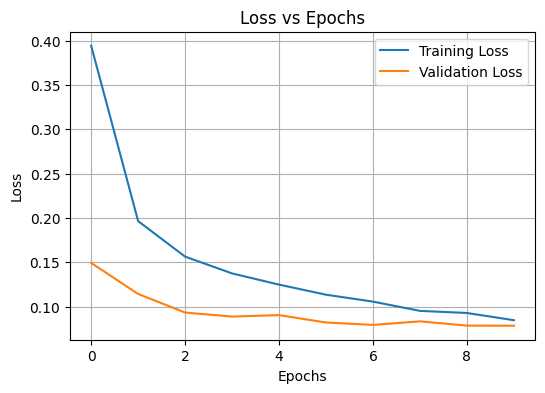

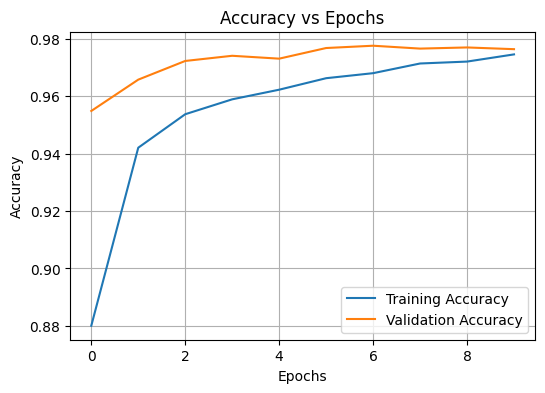

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.datasets import mnist


(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)

model = Sequential()

model.add(Dense(128, input_shape=(784,)))

model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.3))

model.add(Dense(64))

model.add(tf.keras.layers.Activation('relu'))
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(X_train, y_train,epochs=10,validation_data=(X_test, y_test))

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()
plt.grid()
plt.show()

